## Introduction to Data Mining & Machine Learning

### Data Representation in SciKit

Most ML algorithms implemented in Scikit-Learn expect data to be stored in an N-dimensional array or matrix.

* **n_samples** X rows.
The number of samples: each sample is an item to process (e.g. classify). A sample can be a document, a picture, a sound, a video, an astronomical object, a row in database or CSV file, or whatever you can describe with a fixed set of quantitative traits.

* **n_features** Y columns.
The number of features or distinct traits that can be used to describe each item in a quantitative manner. Features are generally real-valued, but may be boolean or discrete-valued in some cases. Often we call them "dimensions".

### Supervised vs Unsupervised

* **Supervised** Training set has labels (in scikit target). The dataset consists in features and labels. The task is to construct an estimator that is able to predict the label of an object given the set of features. To divide in **Classification** (discrete targets) and **Regression** (continuos targets). 

* **Unsupervised** Here the data has no labels, interested in finding similarities between the objects in question, you can think of unsupervised learning as a means of discovering labels from the data itself. Unsupervised learning comprises tasks such as **dimensionality reduction**, **clustering**, and **density estimation**.

### Scikit-learn's estimator interface

Based on the coherent architecture called API

* Available in **all Estimators**
    * `model.fit()`: fit training data. For supervised learning applications, this accepts two arguments: the data `X` and the labels `y` [e.g., `model.fit(X, y)`]. For unsupervised learning applications, this accepts only a single argument, the data `X` [e.g., `model.fit(X)`].
* Available in **supervised estimators**
    * `model.predict()`: given a trained model, predict the label of a new set of data. This method accepts one argument, the new data `X_new` [e.g., `model.predict(X_new)`], and returns the learned label for each object in the array.
    * `model.predict_proba()`: For classification problems, some estimators also provide this method, which returns the probability that a new observation has each categorical label. In this case, the label with the highest probability is returned by `model.predict()`.
    * `model.score()`: For classification or regression problems, most (all?) estimators implement a score method. Scores are between 0 and 1, with a larger score indicating a better fit.
* Available in **unsupervised estimators**
    * `model.transform()`: given an unsupervised model, transform new data into the new basis. This also accepts one argument `X_new`, and returns the new representation of the data based on the unsupervised model.
    * `model.fit_transform()`: some estimators implement this method, which more efficiently performs a fit and a transform on the same input data.
    * `model.score()`: also implemented for unsupervised, depending on the algorithm (clusering:kmeans, density:GMM, data_reduction:PCA) computes some function to evaluate how well the model describes the internal data structure. In gmm and pca it computes the log likelihood. They are sort of **structural metrics**

## Tasks

### Tasks. Part 1. Unsupervised Learning: Dimensionality Reduction on Digits

In [ ]:
from sklearn import datasets
digits = datasets.load_digits()

(1797, 2)
[[ -1.25946645 -21.27488348]
 [  7.9576113   20.76869896]
 [  6.99192297   9.95598641]
 [-15.90610526  -3.33246429]
 [ 23.30686741  -4.26906083]]


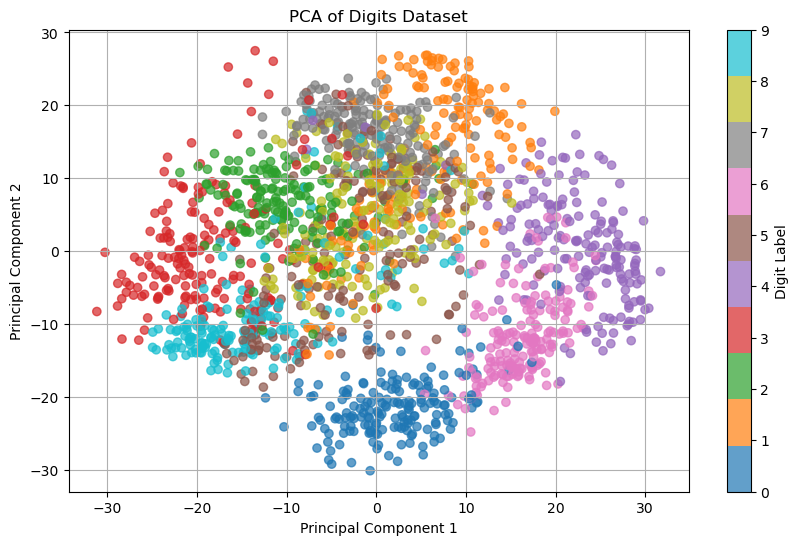

In [ ]:
#reduction with PCA
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
data = digits.data
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(data)
print(reduced_data.shape)
print(reduced_data[:5])

#plotting the reduced data
plt.figure(figsize=(10, 6))
scatter = plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=digits.target, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, ticks=range(10), label='Digit Label')
plt.title('PCA of Digits Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid()
plt.show()



/opt/anaconda3/lib/python3.12/site-packages/sklearn/manifold/_isomap.py:386: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/opt/anaconda3/lib/python3.12/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])


(1797, 2)
[[162.58881242  27.21966931]
 [-46.79288172  48.38888043]
 [-98.0223123   21.77269113]
 [ 44.11787535 -65.38825587]
 [ 29.77319411 158.60705269]]


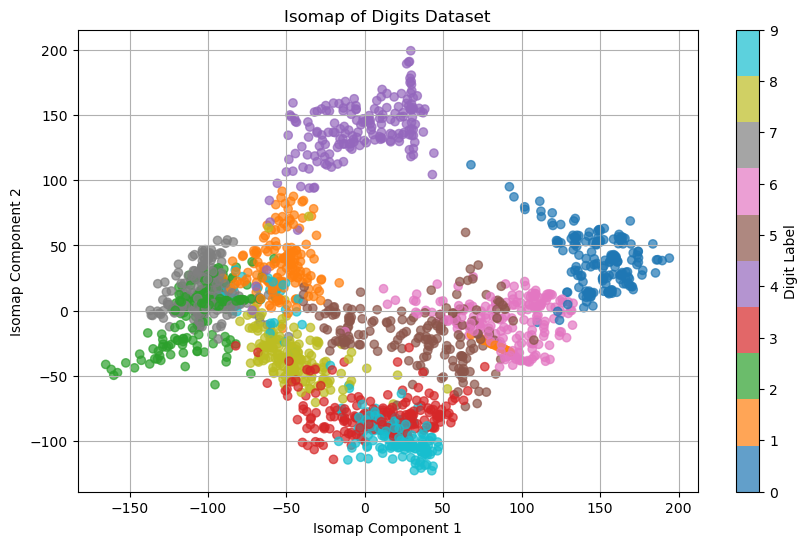

In [27]:
#reduction with Isomap
from sklearn.manifold import Isomap
isomap = Isomap(n_components=2)
isomap_data = isomap.fit_transform(data)
print(isomap_data.shape)
print(isomap_data[:5])

#plotting the reduced data from Isomap
plt.figure(figsize=(10, 6))
scatter = plt.scatter(isomap_data[:, 0], isomap_data[:, 1], c=digits.target, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, ticks=range(10), label='Digit Label')
plt.title('Isomap of Digits Dataset')
plt.xlabel('Isomap Component 1')
plt.ylabel('Isomap Component 2')
plt.grid()
plt.show()

### Tasks. Part 2. Supervised Learning: Classification on Digits

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

test_splittig = {
    '0.2' : 0.2,
    '0.4' : 0.4,
    '0.6' : 0.6,
    '0.8' : 0.8,
}

X_train, X_test, y_train, y_test = train_test_split(data, digits.target, test_size=0.4, random_state=42) 
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

model = LogisticRegression(solver='sag', max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

#facciamo variare la test_size per vedere come cambia la matrice di confusione
X_train, X_test, y_train, y_test = train_test_split(data, digits.target, test_size=0.2, random_state=42) 
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))

#valutiamo accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

(1078, 64) (719, 64)
(1078,) (719,)
[[67  0  0  0  0  0  0  0  0  0]
 [ 0 67  1  0  1  0  0  0  2  1]
 [ 0  0 66  0  0  0  0  0  0  0]
 [ 0  0  1 69  0  1  0  0  0  0]
 [ 0  1  0  0 76  0  1  0  0  0]
 [ 0  1  0  0  0 79  1  0  0  2]
 [ 0  0  0  0  0  1 68  0  0  0]
 [ 0  0  0  0  0  0  0 70  0  1]
 [ 0  3  0  0  0  1  0  0 61  0]
 [ 0  0  0  1  0  0  0  0  3 73]]
Accuracy: 0.9680
(1437, 64) (360, 64)
(1437,) (360,)
[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  1  0  0 45  0  0  0  0  0]
 [ 0  0  0  0  0 45  1  0  0  1]
 [ 0  0  0  0  0  1 34  0  0  0]
 [ 0  0  0  0  0  1  0 33  0  0]
 [ 0  0  0  0  0  1  0  0 29  0]
 [ 0  0  0  1  0  0  0  0  1 38]]
Accuracy: 0.9750


### Quale scegliere?

Usa la PCA quando: Hai dataset molto grandi, vuoi qualcosa di molto veloce e presumi che le relazioni tra le tue variabili siano per lo più lineari.

Usa Isomap quando: Stai analizzando dati complessi (come immagini di volti ripresi da angolazioni diverse, o dati sensoriali complessi) in cui pensi ci sia una geometria nascosta curva o "arrotolata". Tieni presente che Isomap è molto più lento della PCA perché deve calcolare i percorsi su un grafo.